# Regression
## B0: Install Library (Sklearn)
## B1: Load Library
## B2: Load Data
## B3: Preprocessing
## B4: Build Model
## B5: Validation

## B0. Install Library

In [1]:
!pip install scikit-learn

In [2]:
!pip install statsmodels

In [3]:
!pip install scikit-learn

## B1. Load Library

In [1]:
import pandas as pd
#LinearRegression(class), train_test_split (function)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant
from statsmodels.formula.api import ols

In [2]:
data = ['d1', 'd2', 'd3', 'd4', 'd5']
data_train, data_test = train_test_split(data, random_state = 2026)
data_train, data_test

(['d4', 'd3', 'd2'], ['d5', 'd1'])

## B2. Load Data

In [3]:
df = pd.read_csv('./data/Advertising.xls', index_col = 0)
df.head(n=3)

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3


## Covarian (hiệp phương sai)
$$cov(x, y) = \frac{\sum (x_i -\bar{x}) * (y_i - \bar{y})}{n}$$

In [4]:
df[['TV', 'Radio', 'Newspaper']].cov()

,TV,Radio,Newspaper
TV,7370.949893,69.862492,105.919452
Radio,69.862492,220.427743,114.496979
Newspaper,105.919452,114.496979,474.308326


## Variance

$$var(x) = \sigma_x^2 = \frac{\sum (x_i - \bar{x})^2}{n}$$

$$std(x) = \sigma_x = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n}}$$
## Correlation
$$corr(x, y) = \frac{cov(x, y)}{\sigma_x * \sigma_y}$$

$$corr(x, y) = \frac{\sum (x_i - \bar{x}) * (y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2} * \sqrt{\sum (y_i - \bar{y})^2}}$$

$$ -1 \leq corr \leq 1 $$

In [5]:
df[['TV', 'Radio', 'Newspaper']].corr()

,TV,Radio,Newspaper
TV,1.000000,0.054809,0.056648
Radio,0.054809,1.000000,0.354104
Newspaper,0.056648,0.354104,1.000000


In [6]:
df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


## B4. Preprocessing

In [7]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## B5. Build Model

In [8]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X = add_constant(X)

# Phương pháp bình phương nhỏ nhất
model = OLS(endog=y, exog=X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.58e-96
Time:                        06:23:03   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
Radio          0.1885      0.009     21.893      0.000       0.172       0.206
Newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Giả thiết
h0: newspaper = 0
ha: newspaper != 0
### do p-value_{newspaper} = 0.86 > 0.05 => không thể bác bỏ giả thiết H0,  newspaper ~ 0, bỏ biến newspaper

## chạy mô hình với hai biến TV và Radio

In [9]:
X = df[['TV', 'Radio']]
y = df['Sales']

X = add_constant(X)

# Phương pháp bình phương nhỏ nhất
model = OLS(endog=y, exog=X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           4.83e-98
Time:                        06:23:07   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9211      0.294      9.919      0.000       2.340       3.502
TV             0.0458      0.001     32.909      0.000       0.043       0.048
Radio          0.1880      0.008     23.382      0.000       0.172       0.204
==============================================================================
Omnibus:                       60.022   Durbin-Watson:                   2.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.679
Skew:                          -1.323   Prob(JB):                     5.19e-33
Kurtosis:                       6.292   Cond. No.                         425.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Statmodel(formula)

In [10]:
model = ols(formula='Sales ~ TV + Newspaper', data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     179.6
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           3.95e-45
Time:                        06:23:10   Log-Likelihood:                -509.89
No. Observations:                 200   AIC:                             1026.
Df Residuals:                     197   BIC:                             1036.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.7749      0.525     10.993      0.000       4.739       6.811
TV             0.0469      0.003     18.173      0.000       0.042       0.052
Newspaper      0.0442      0.010      4.346      0.000       0.024       0.064
==============================================================================
Omnibus:                        0.658   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.720   Jarque-Bera (JB):                0.415
Skew:                          -0.093   Prob(JB):                        0.813
Kurtosis:                       3.122   Cond. No.                         410.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
model = ols(formula='Sales ~ TV + Radio', data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           4.83e-98
Time:                        06:23:14   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9211      0.294      9.919      0.000       2.340       3.502
TV             0.0458      0.001     32.909      0.000       0.043       0.048
Radio          0.1880      0.008     23.382      0.000       0.172       0.204
==============================================================================
Omnibus:                       60.022   Durbin-Watson:                   2.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.679
Skew:                          -1.323   Prob(JB):                     5.19e-33
Kurtosis:                       6.292   Cond. No.                         425.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [13]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026)

lg = LinearRegression()
lg.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
lg.coef_, lg.intercept_

(array([0.04718589, 0.19273099, 0.00546507]), np.float64(2.392288665420608))

In [15]:
df_coef = pd.DataFrame({
    'coef': lg.coef_,
    'features': X.columns
}).sort_values(by='coef')
df_coef


,coef,features
2,0.005465,Newspaper
0,0.047186,TV
1,0.192731,Radio


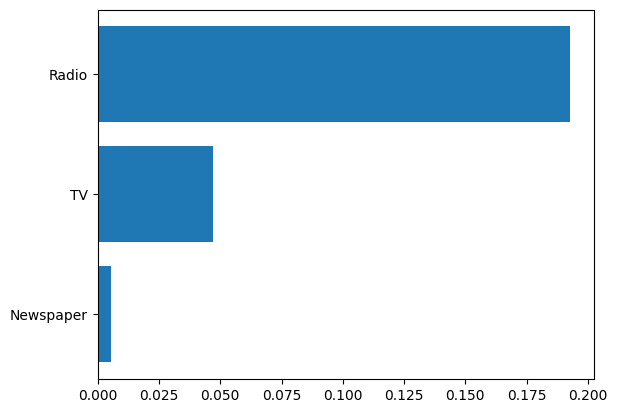

In [16]:
# plt.barh()
plt.barh(y=df_coef['features'], width=df_coef['coef'])
plt.show()

## B6: Validation

### 6.1 R^2
$$r^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
$$r^2 \le 1 $$

In [17]:
# Method score
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.9098307456693421, 0.8168924328334581)

In [18]:
predict_train = lg.predict(X_train)
predict_test = lg.predict(X_test)
# predict = lg.predict(X)
# function r2_score
r2_score(y_train, predict_train), r2_score(y_test, predict_test)

(0.9098307456693421, 0.8168924328334581)

### 6.2 Mean Square Error
$$MSE = \frac{\sum (y_i - \hat{y}_i)^2}{n}$$

In [19]:
mean_squared_error(y_train, predict_train), mean_squared_error(y_test, predict_test)

(2.617668596727426, 3.480860935660857)

# Timeseries
## Thời tiết, mực nước, giá cổ phiếu, doanh thu hằng ngày, CPI(giỏ hàng )

## B0. Install Library

In [20]:
!pip install yfinance

## B1. Load Library

In [21]:
import yfinance as yfs
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np  

In [22]:
data = ['t1', 't2', 't3', 't4', 't5']
data_train, data_test = train_test_split(data)
data_train, data_test

(['t5', 't4', 't1'], ['t3', 't2'])

In [23]:
data_train, data_test = train_test_split(data, shuffle=False)
data_train, data_test

(['t1', 't2', 't3'], ['t4', 't5'])

## B2. Load Data

In [27]:
ticker = yfs.Ticker('AMZN')
data = ticker.history(period='20y')

In [28]:
data.to_csv('./data/AMZN.csv')

In [29]:
df =  pd.read_csv('./data/AMZN.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2006-03-06 00:00:00-05:00,1.8660,1.8790,1.8385,1.8430,85166000,0.0,0.0
1,2006-03-07 00:00:00-05:00,1.8355,1.8710,1.8350,1.8465,94446000,0.0,0.0
2,2006-03-08 00:00:00-05:00,1.8360,1.8735,1.8305,1.8405,124732000,0.0,0.0
3,2006-03-09 00:00:00-05:00,1.8400,1.8480,1.7950,1.8060,144002000,0.0,0.0
4,2006-03-10 00:00:00-05:00,1.8120,1.8250,1.7870,1.8110,99454000,0.0,0.0


In [30]:
df['Date'] = pd.to_datetime(df['Date'], utc = True)

In [31]:
df['Date'][0]

Timestamp('2006-03-06 05:00:00+0000', tz='UTC')

In [32]:
df.set_index('Date', inplace=True)

In [33]:
df.head(n =2)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2006-03-06 05:00:00+00:00,1.8660,1.879,1.8385,1.8430,85166000,0.0,0.0
2006-03-07 05:00:00+00:00,1.8355,1.871,1.8350,1.8465,94446000,0.0,0.0


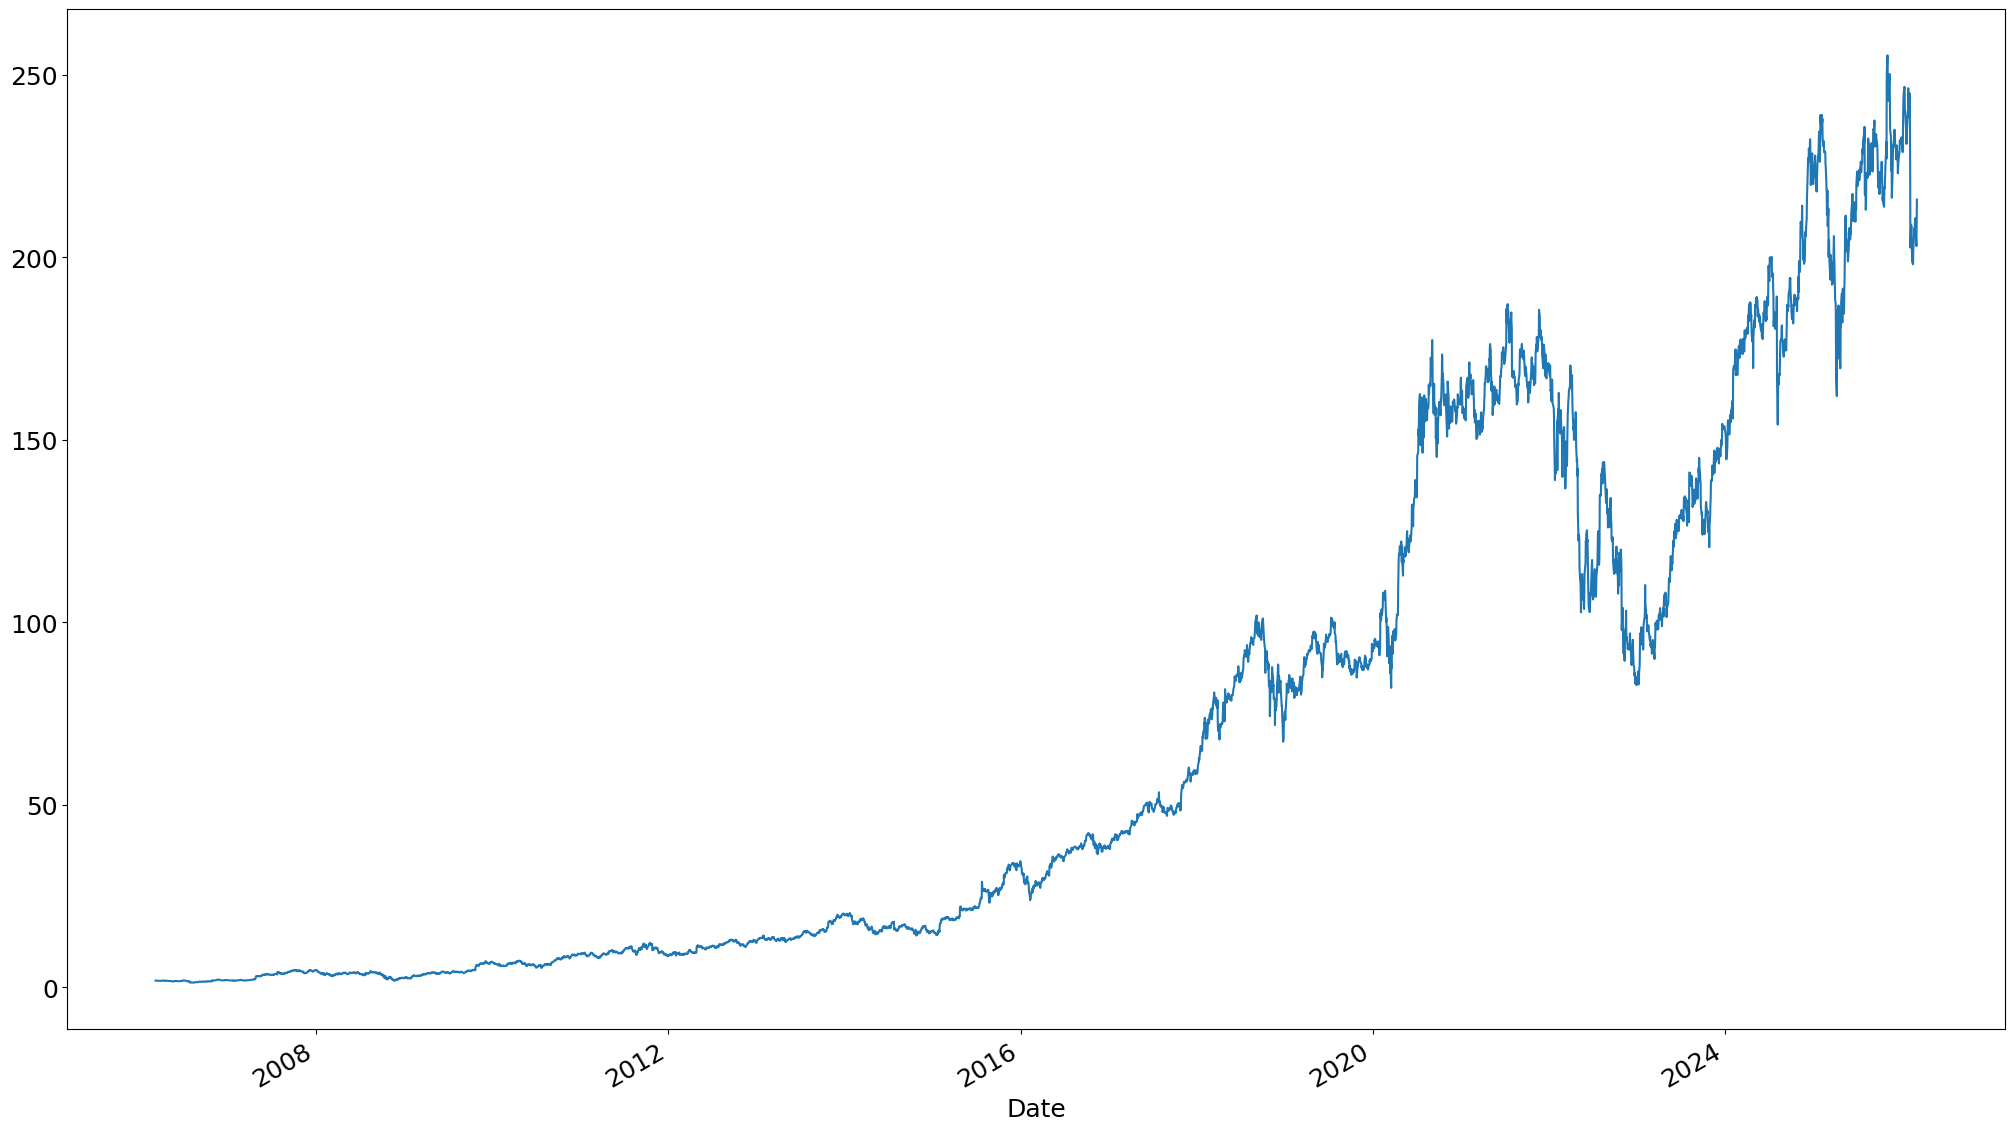

In [34]:
plt.rcParams['font.size'] = 18
plt.figure(figsize=(25, 15))
df['Open'].plot()
plt.show()

## B4: Build Model

## Native X = t, y = open

In [35]:
X = np.arange(df.shape[0]).reshape((df.shape[0], 1))
y = df['Open']
X.shape, y.shape

((5032, 1), (5032,))

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)
lg = LinearRegression()
lg.fit(X_train, y_train)
y_train_pred = lg.predict(X_train)
y_test_pred = lg.predict(X_test)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.7152531810890826, -1.2099389911050502)

In [37]:
df['train_predict'] = y_train_pred.tolist() + [np.nan] * y_test_pred.shape[0]
df['test_predict'] = [np.nan] * y_train_pred.shape[0] + y_test_pred.tolist()
df.head(n = 2)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,train_predict,test_predict
Date,,,,,,,,,
2006-03-06 05:00:00+00:00,1.8660,1.879,1.8385,1.8430,85166000,0.0,0.0,-26.258304,NaN
2006-03-07 05:00:00+00:00,1.8355,1.871,1.8350,1.8465,94446000,0.0,0.0,-26.226314,NaN


In [38]:
df.shape, y_train_pred.shape, y_test_pred.shape

((5032, 9), (3774,), (1258,))

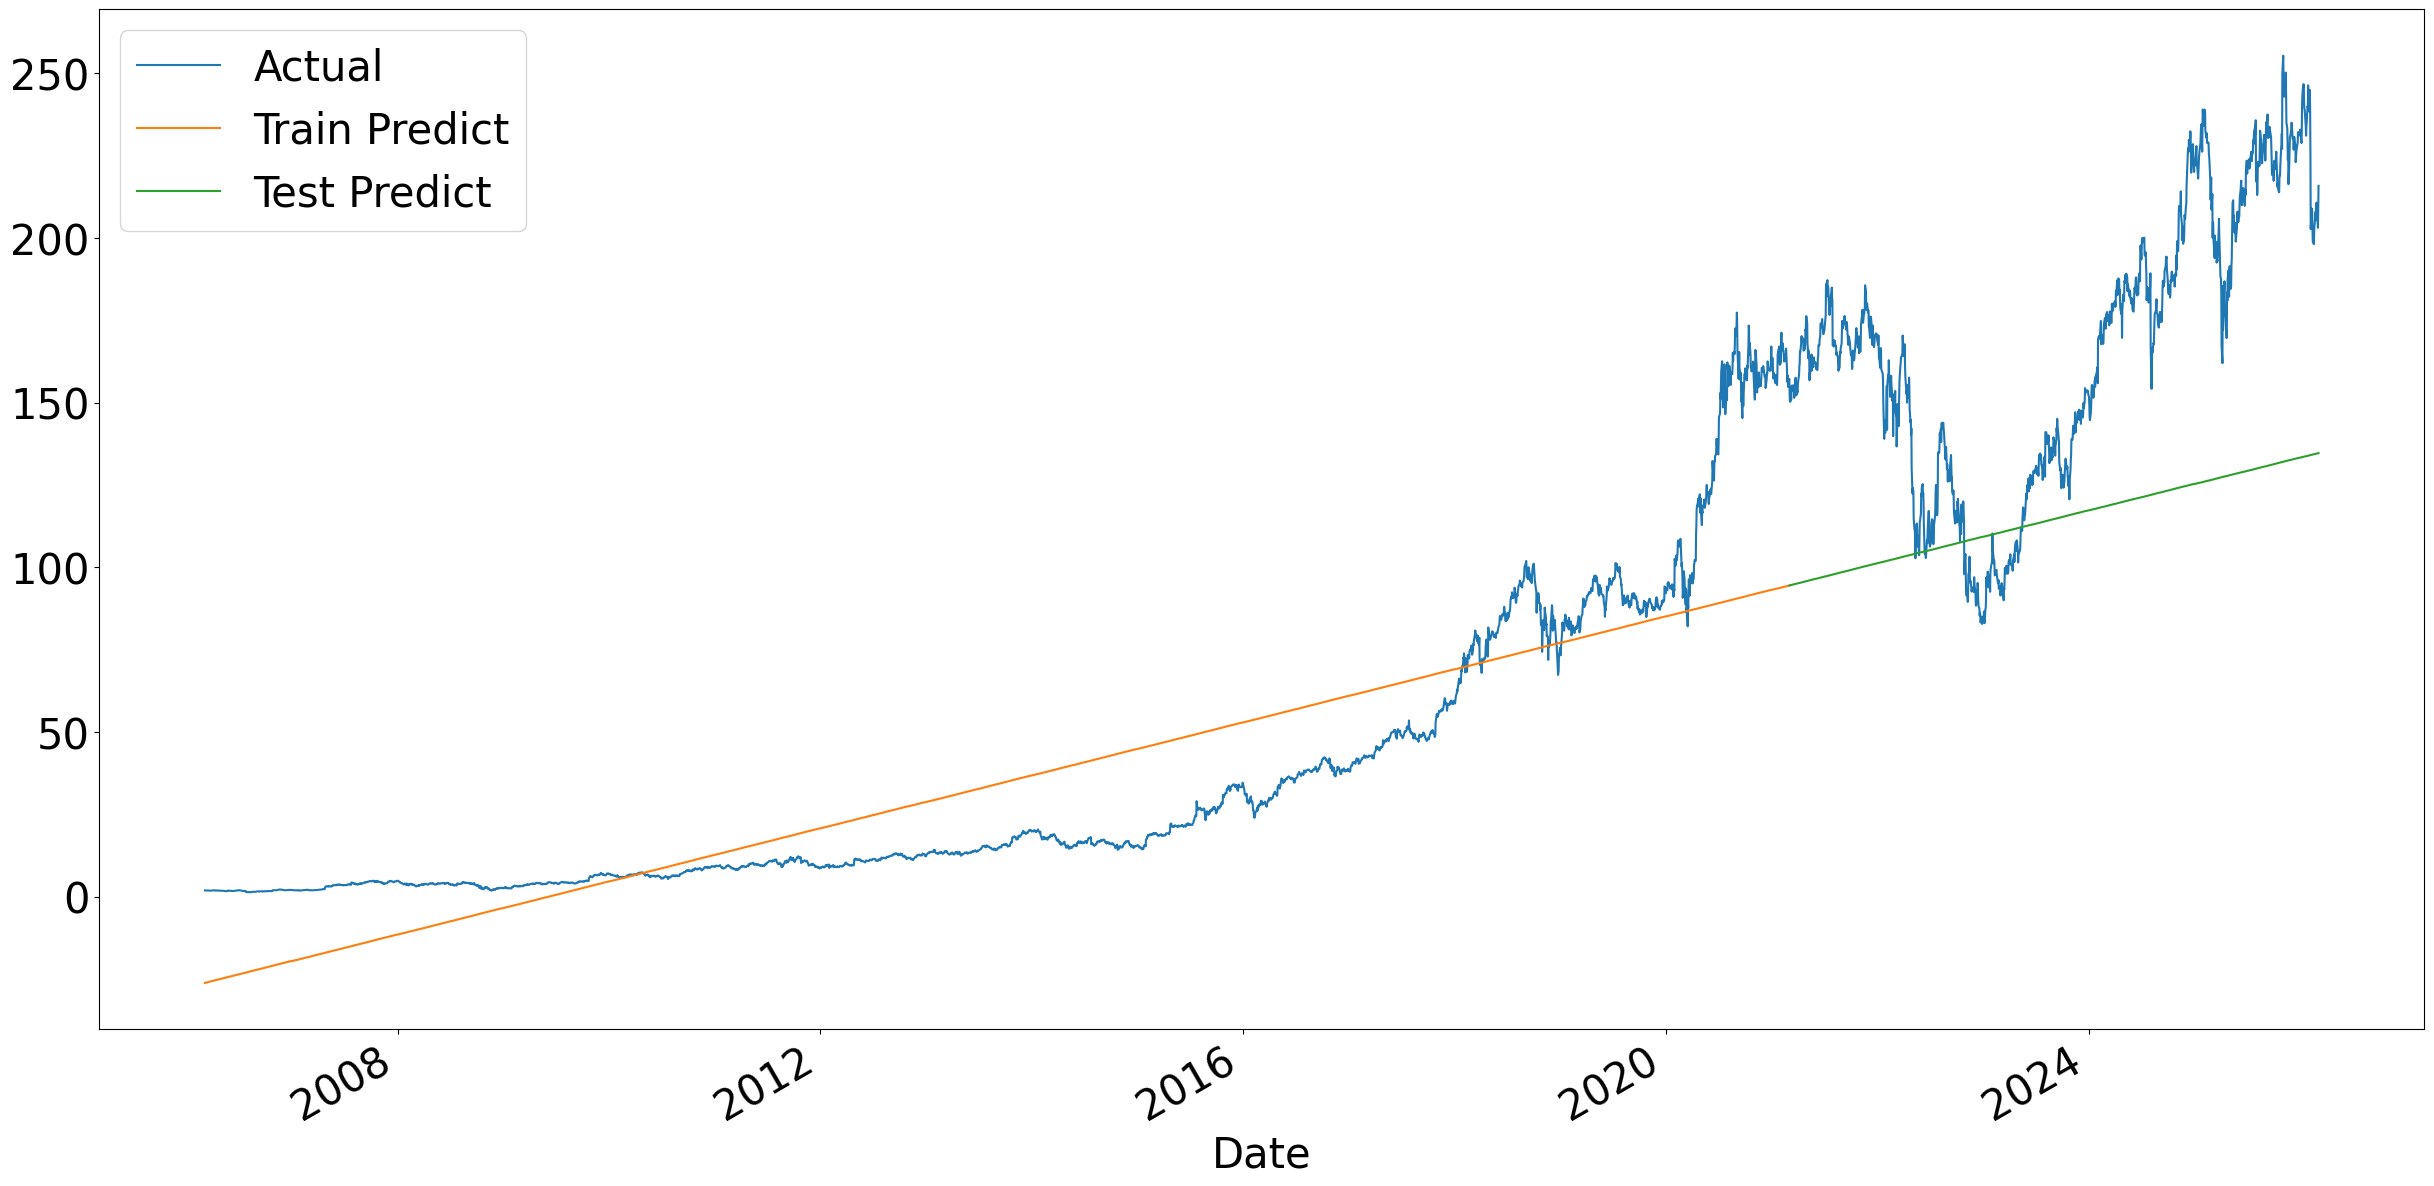

In [39]:
plt.rcParams['font.size'] = 30
plt.figure(figsize=(30, 15))
df['Open'].plot()
df['train_predict'].plot()
df['test_predict'].plot()
plt.legend(['Actual', 'Train Predict', 'Test Predict'])
plt.show()

### Overfiting (r^2 train tốt), (r^2 test tệ)
### Underfiting (r^2 train tệ)

## Auto Regression

In [40]:
dat = pd.DataFrame({
    'Open': [9, 7, 8, 6, 5]
})
window_size = 2
m = dat.shape[0] - window_size
# dat['Open'].values[0:m], dat['Open'].values[1:m + 1], dat['Open'].values[window_size:]
data = {}
for i in range(window_size):
    data[f'x{i}'] = dat['Open'].values[i:m + i]
data['y'] = dat['Open'].values[window_size:]
pd.DataFrame(data)

,x0,x1,y
0,9,7,8
1,7,8,6
2,8,6,5


In [41]:
window_size = 3
data = {}
y = []
m = df.shape[0] - window_size
for i in range(window_size):
    data[f'x{i}'] = df['Open'].values[i:m + i]
data['y'] = df['Open'].values[window_size:]
df2 = pd.DataFrame(data)
df2.head()

,x0,x1,x2,y
0,1.8660,1.8355,1.8360,1.8400
1,1.8355,1.8360,1.8400,1.8120
2,1.8360,1.8400,1.8120,1.8155
3,1.8400,1.8120,1.8155,1.8020
4,1.8120,1.8155,1.8020,1.8475


In [42]:
X = df2.drop(columns='y')
y = df2['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

In [43]:
lg = LinearRegression()
lg.fit(X_train, y_train)
y_train_pred = lg.predict(X_train)
y_test_pred = lg.predict(X_test)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.999227192443017, 0.9923040038724563)

In [44]:
df['train_predict2'] = [np.nan] * window_size + y_train_pred.tolist() + [np.nan] * y_test_pred.shape[0]
df['test_predict2'] = [np.nan] * (window_size + y_train_pred.shape[0]) + y_test_pred.tolist()
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,train_predict,test_predict,train_predict2,test_predict2
Date,,,,,,,,,,,
2006-03-06 05:00:00+00:00,1.8660,1.8790,1.8385,1.8430,85166000,0.0,0.0,-26.258304,NaN,NaN,NaN
2006-03-07 05:00:00+00:00,1.8355,1.8710,1.8350,1.8465,94446000,0.0,0.0,-26.226314,NaN,NaN,NaN
2006-03-08 05:00:00+00:00,1.8360,1.8735,1.8305,1.8405,124732000,0.0,0.0,-26.194325,NaN,NaN,NaN
2006-03-09 05:00:00+00:00,1.8400,1.8480,1.7950,1.8060,144002000,0.0,0.0,-26.162336,NaN,1.854839,NaN
2006-03-10 05:00:00+00:00,1.8120,1.8250,1.7870,1.8110,99454000,0.0,0.0,-26.130346,NaN,1.857104,NaN


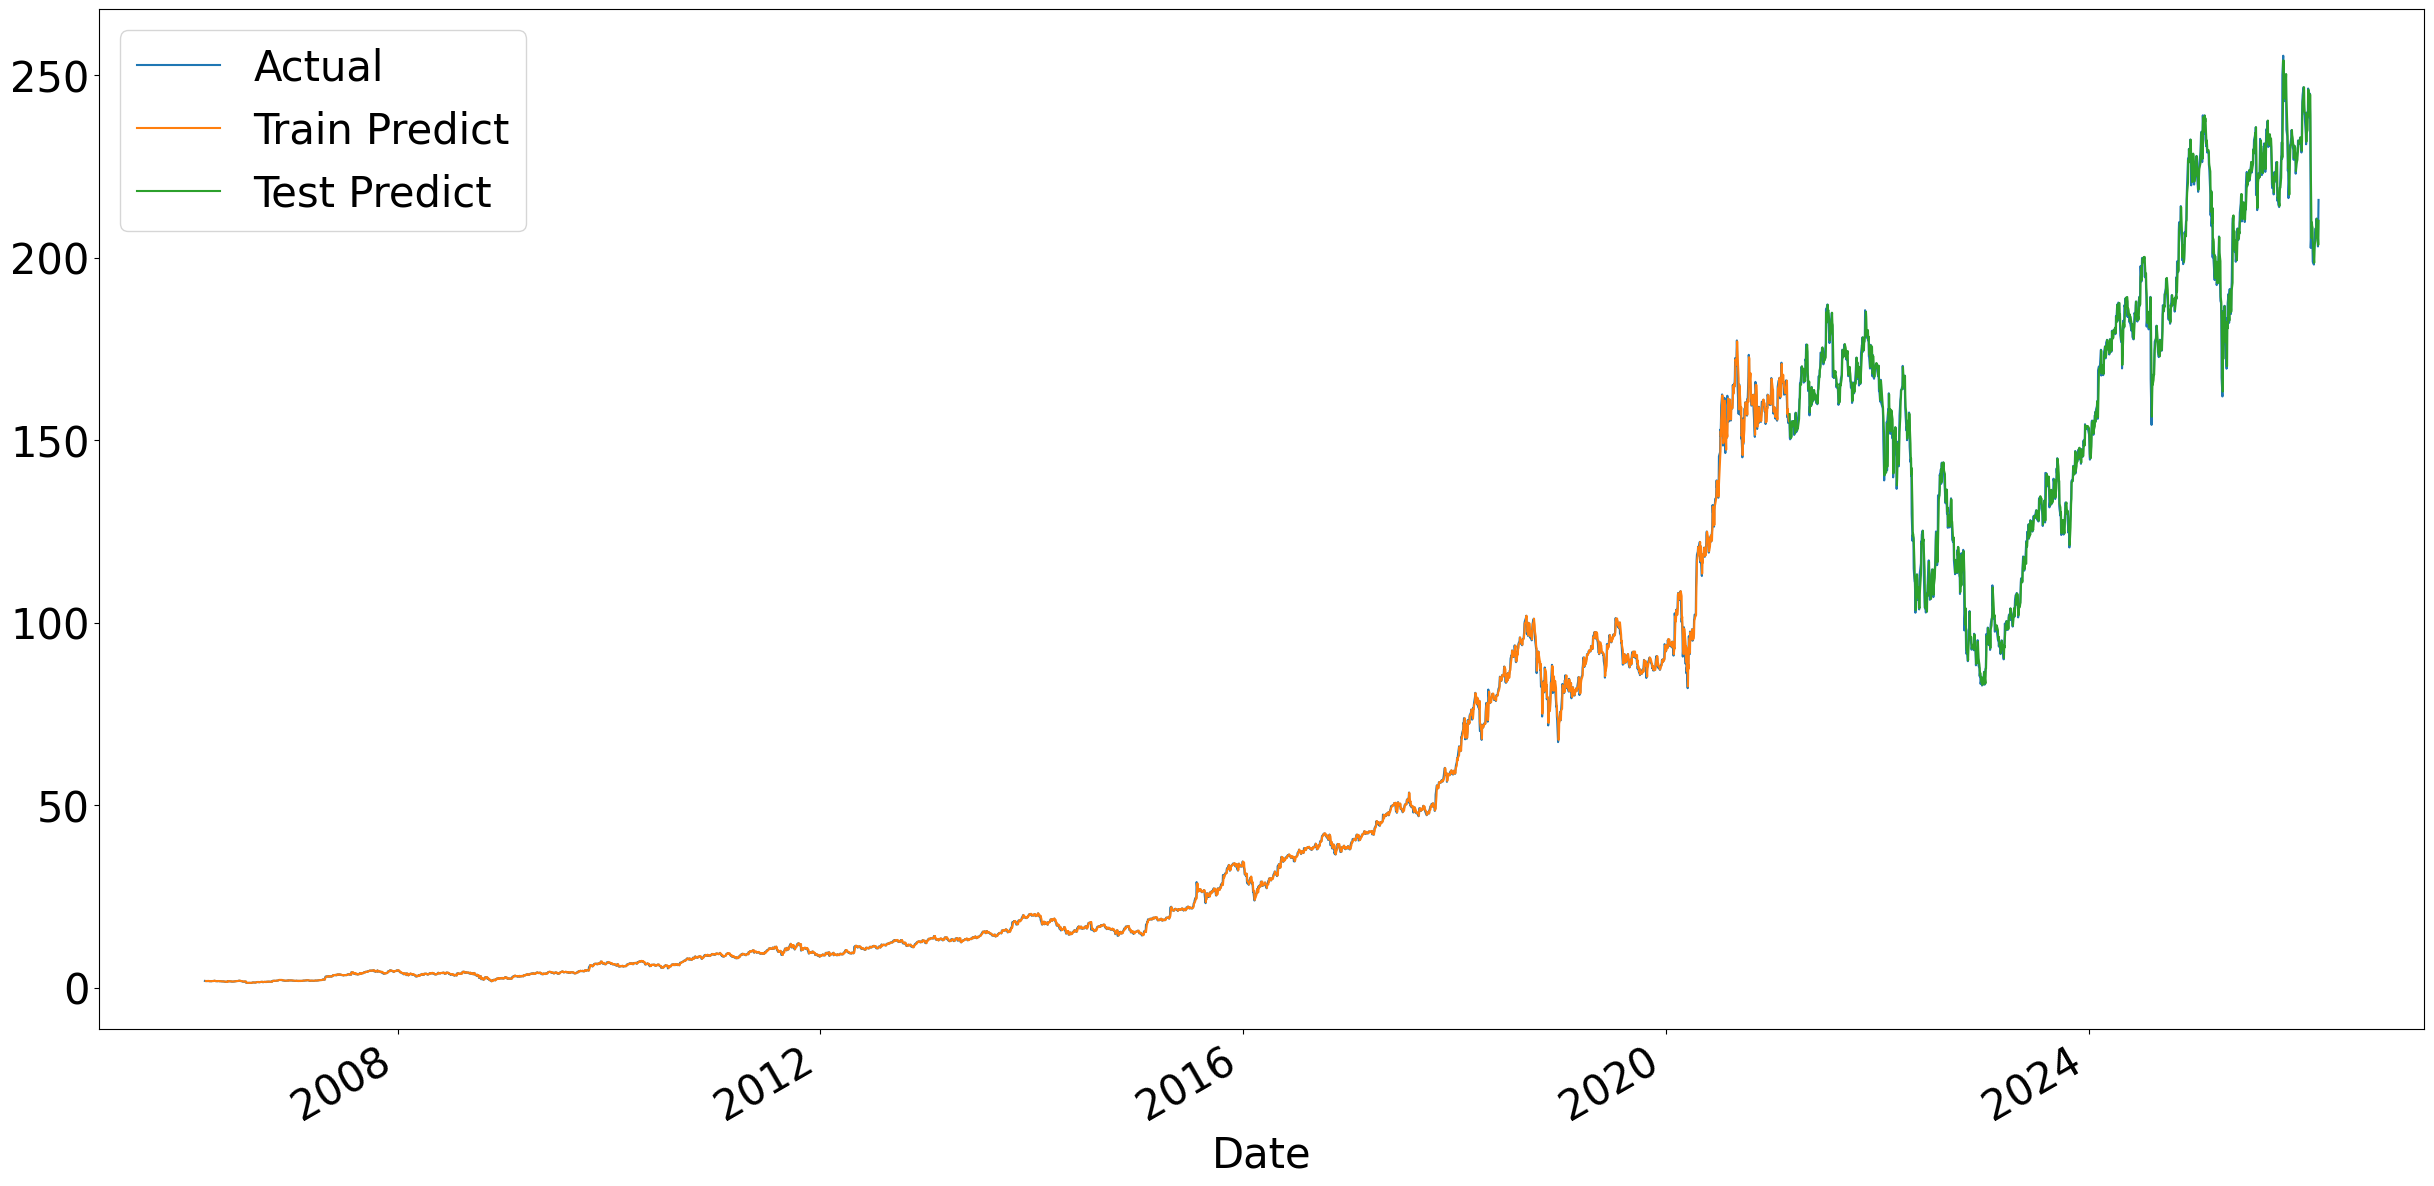

In [45]:
plt.rcParams['font.size'] = 30
plt.figure(figsize=(30, 15))
df['Open'].plot()
df['train_predict2'].plot()
df['test_predict2'].plot()
plt.legend(['Actual', 'Train Predict', 'Test Predict'])
plt.show()

In [46]:
!pip install mlxtend


In [47]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

In [14]:
data = pd.DataFrame([
    ['T1', ['Hot Dogs', 'Buns', 'Ketchup']],
    ['T2', ['Hot Dogs', 'Buns']],
    ['T3', ['Hot Dogs', 'Coke', 'Chips']],
    ['T4', ['Chips', 'Coke']],
    ['T5', ['Chips', 'Ketchup']],
    ['T6', ['Hot Dogs', 'Coke', 'Chips']]
], 
columns=['Transaction', 'itemset'])

encoder = TransactionEncoder()
encoder.fit(data['itemset'])
df = pd.DataFrame(data = encoder.transform(data['itemset']), columns=encoder.columns_, dtype=int)

apriori(df, min_support=0.3, use_colnames=True)

d:\Python\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.333333,(Buns)
1,0.666667,(Chips)
2,0.500000,(Coke)
3,0.666667,(Hot Dogs)
4,0.333333,(Ketchup)
5,0.333333,"(Buns, Hot Dogs)"
6,0.500000,"(Chips, Coke)"
7,0.333333,"(Chips, Hot Dogs)"
8,0.333333,"(Coke, Hot Dogs)"
9,0.333333,"(Chips, Hot Dogs, Coke)"


In [48]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

transactions = [
    ['Hot Dogs', 'Buns', 'Ketchup'],
    ['Hot Dogs', 'Buns'],
    ['Hot Dogs', 'Coke', 'Chips'],
    ['Chips', 'Coke'],
    ['Chips', 'Ketchup'],
    ['Hot Dogs', 'Coke', 'Chips']
]

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(basket, min_support=0.3, use_colnames=True)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

rules[['antecedents','consequents','support','confidence','lift']]

,antecedents,consequents,support,confidence,lift
0,(Buns),(Hot Dogs),0.333333,1.000000,1.5
1,(Coke),(Chips),0.500000,1.000000,1.5
2,(Chips),(Coke),0.500000,0.750000,1.5
3,(Coke),(Hot Dogs),0.333333,0.666667,1.0
4,"(Hot Dogs, Chips)",(Coke),0.333333,1.000000,2.0
5,"(Hot Dogs, Coke)",(Chips),0.333333,1.000000,1.5
6,"(Coke, Chips)",(Hot Dogs),0.333333,0.666667,1.0
7,(Coke),"(Hot Dogs, Chips)",0.333333,0.666667,2.0


### $X \to Y$
### $support(A \to B) = 5%$
### $N$ là tổng số giao dịch, support = $\dfrac{\text{số giao dịch chứa } X \cup Y}{N}$


In [49]:
from collections import deque

def bfs_path(graph, root, goal):
    Q = deque()
    explored = set()
    parent = {}

    explored.add(root)
    Q.append(root)
    parent[root] = None

    while Q:
        v = Q.popleft()

        if v == goal:
            # dựng lại đường đi
            path = []
            while v is not None:
                path.append(v)
                v = parent[v]
            return path[::-1]   # đảo ngược

        for w in graph[v]:
            if w not in explored:
                explored.add(w)
                parent[w] = v
                Q.append(w)

    return None


In [50]:
G = {
    1: [2, 3],
    2: [4, 5],
    3: [6],
    4: [],
    5: [6],
    6: []
}

print(bfs_path(G, 1, 6))


[1, 3, 6]
